# SECCIÓN 3: SHAP 

In [27]:
import os
import joblib
import pandas as pd
import shap
import numpy as np

In [28]:
# Cargar modelo final
ruta_modelo = '/Users/yedisoncuervo/Desktop/Proyecto-4_Analitica_III/src/Mejores_Modelos/lr_1.pkl'
lr_model = joblib.load(ruta_modelo)


In [29]:
# Cargar datos guardados
X_train = pd.read_pickle('/Users/yedisoncuervo/Desktop/Proyecto-4_Analitica_III/Datos/X_train_shap.pkl')
X_test = pd.read_pickle('/Users/yedisoncuervo/Desktop/Proyecto-4_Analitica_III/Datos/X_test_shap.pkl')

In [30]:
# Background representativo
X_background = X_train.sample(n=min(500, len(X_train)), random_state=42)

# Crear explicador SHAP para XGBoost
explainer = shap.LinearExplainer(lr_model, X_background)

# Calcular valores SHAP sobre X_test
shap_values = explainer(X_test)


variables_seleccionadas = X_test.columns.tolist()

Background dataset has 500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=500 when initializing the masker.


# Summary plot tipo beeswarm:

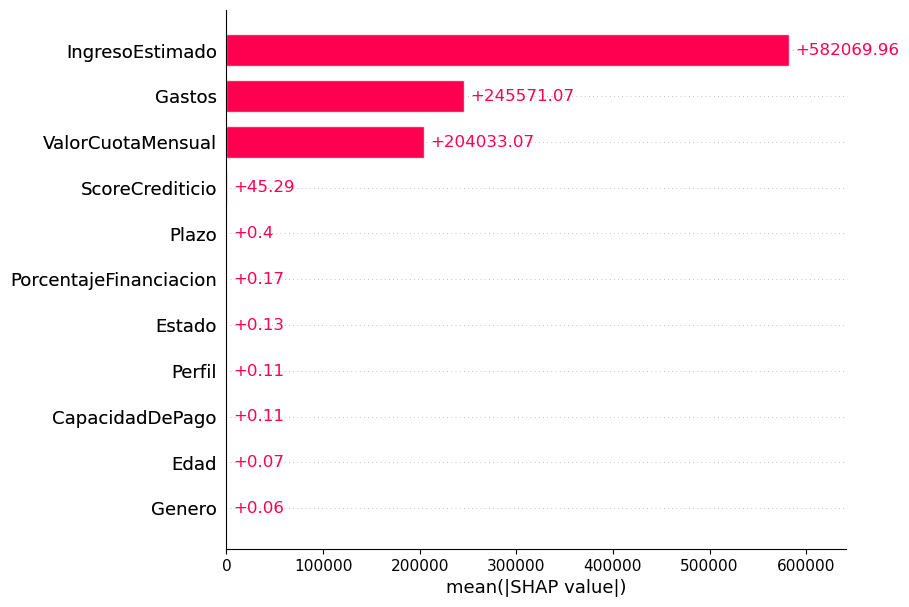

In [31]:
shap.plots.bar(shap_values, max_display=len(variables_seleccionadas))

# Gráfico de dependencia por variable

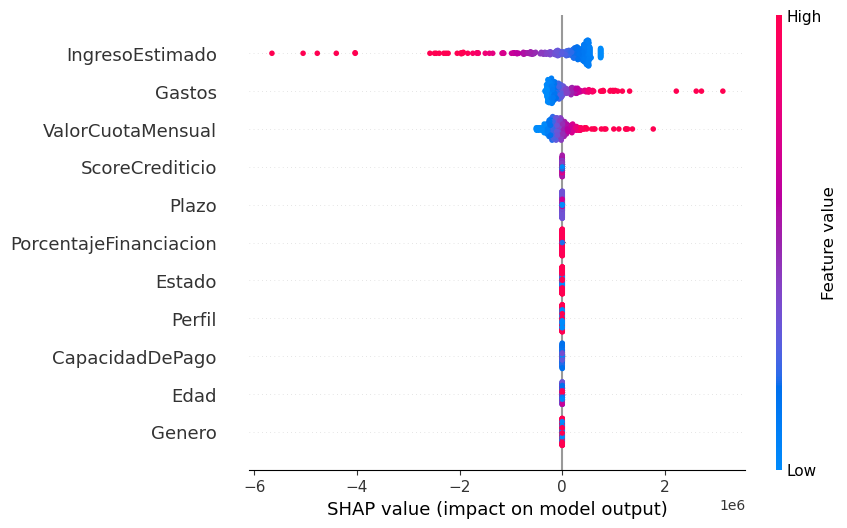

In [32]:
# Visualización de los valores SHAP para las variables seleccionadaS
shap.plots.beeswarm(
    shap_values,
    max_display=len(variables_seleccionadas)
)

# Waterfall plot para una empresa específica

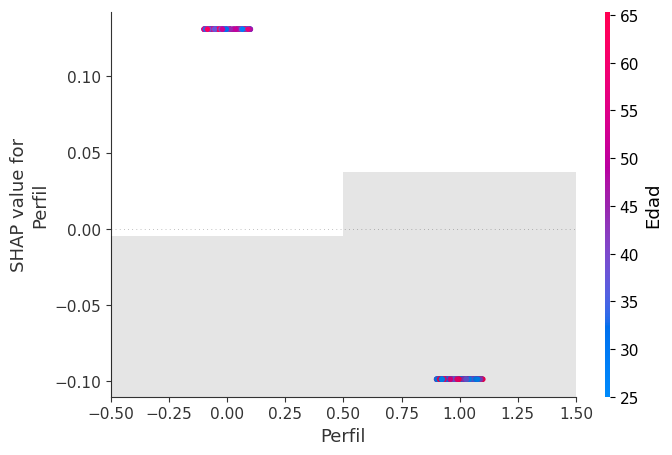

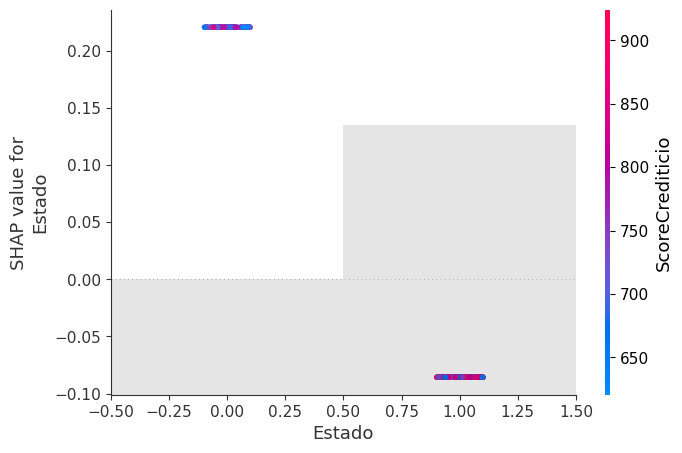

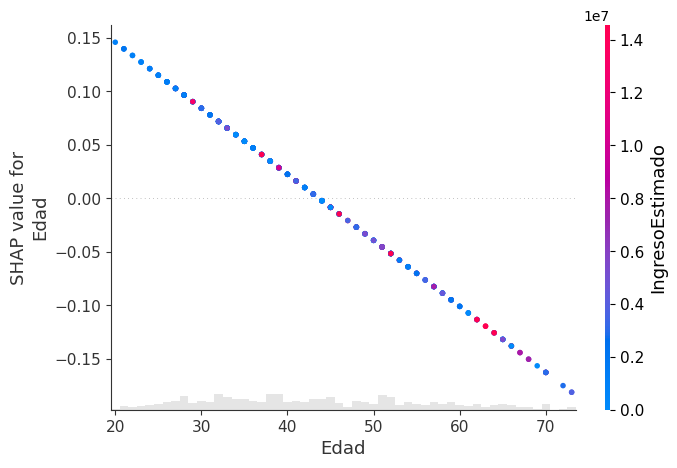

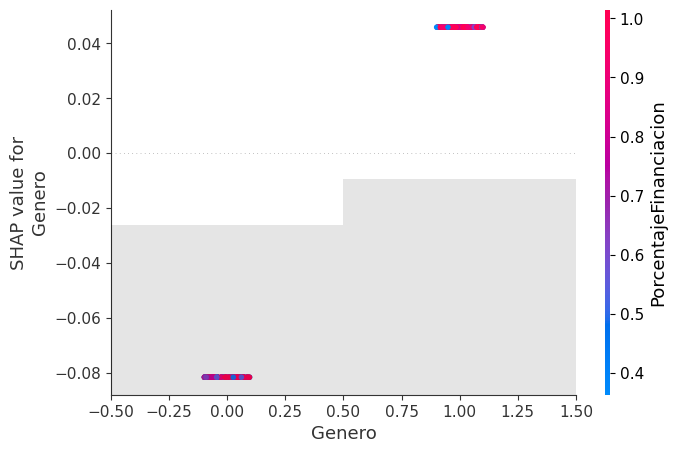

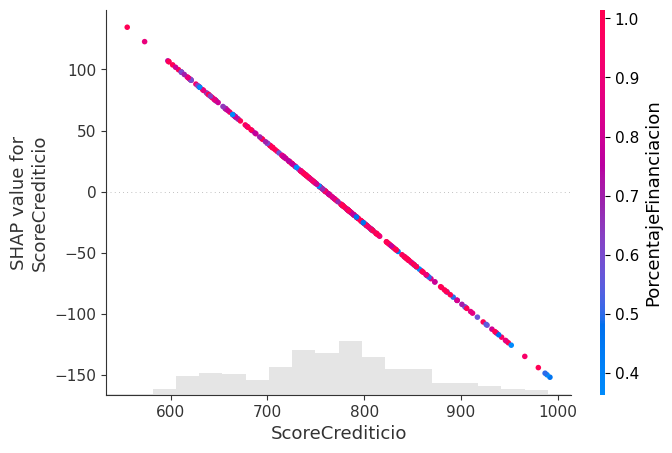

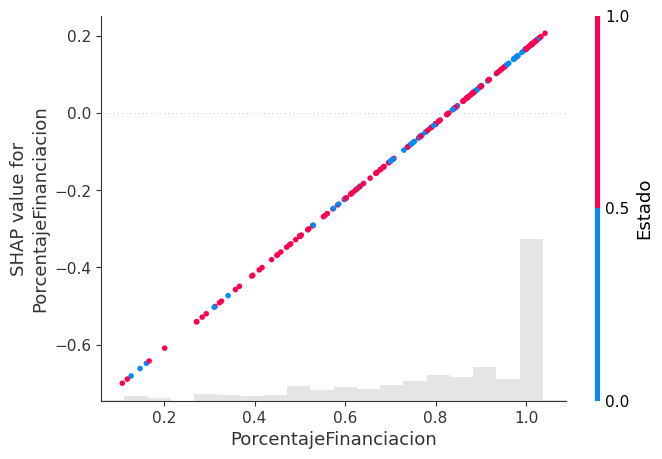

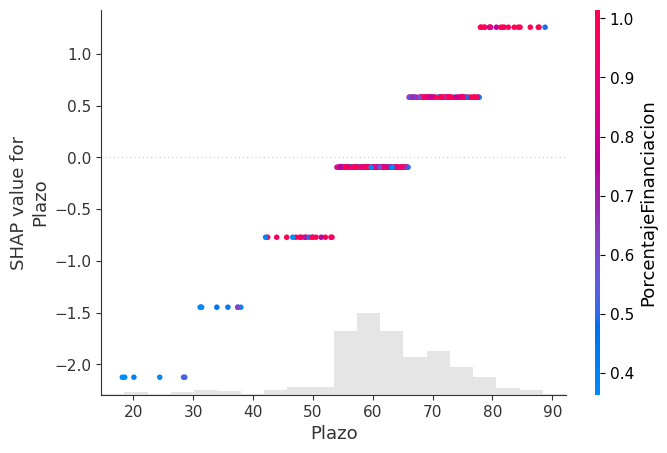

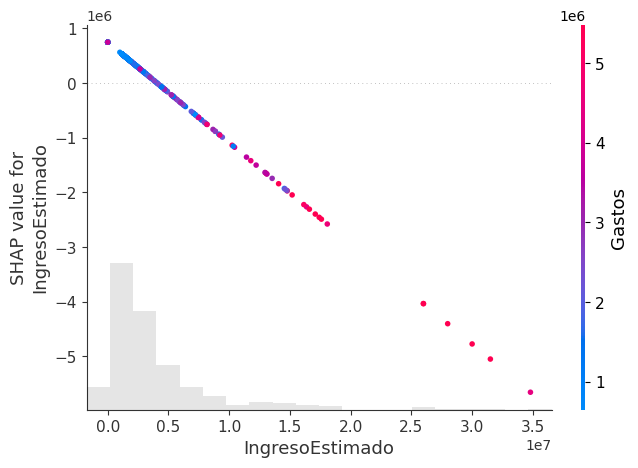

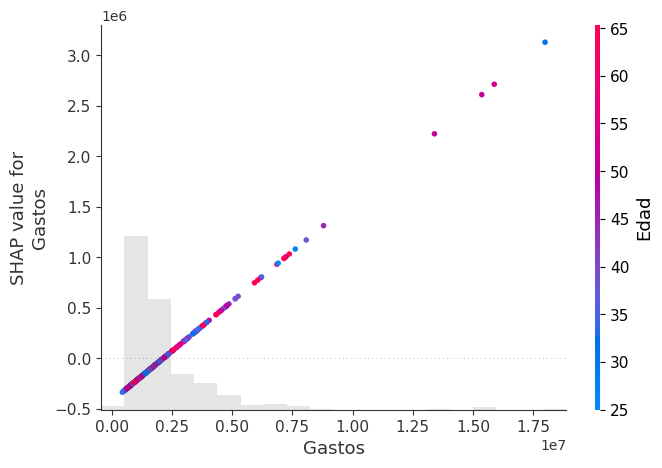

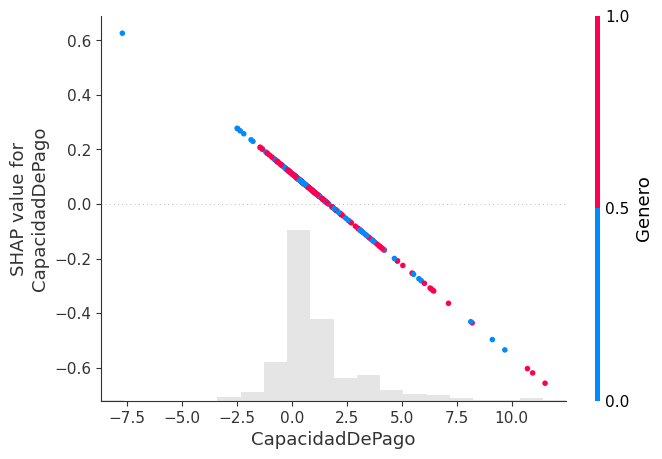

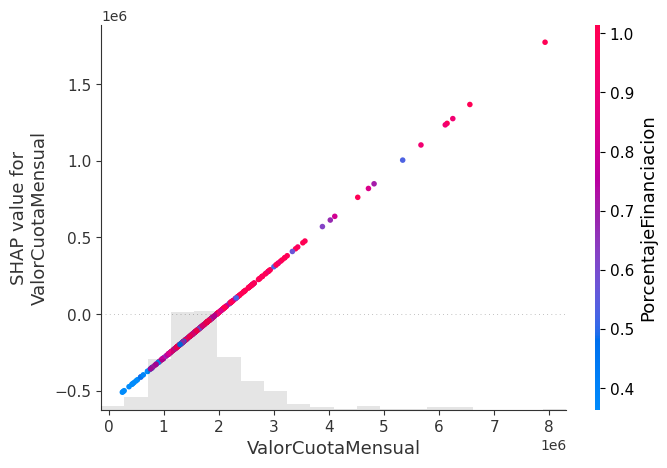

In [33]:
for variable in variables_seleccionadas:
    shap.plots.scatter(
        shap_values[:, variable],
        color=shap_values
    )

# SECCIÓN 4: VALIDACIÓN (10 Muestras)

In [34]:
# Seleccionar 10 muestras aleatorias para validar
ruta_y_test = '/Users/yedisoncuervo/Desktop/Proyecto-4_Analitica_III/Datos/y_test_shap.pkl'

try:
    y_test = pd.read_pickle(ruta_y_test)
except FileNotFoundError:
    y_test = None
    print('Aviso: no se encontro y_test_shap.pkl. Se validara sin etiqueta real.')

n_muestras = 10
semilla_muestreo = None  # None: cambia en cada corrida. Usa un entero si quieres reproducibilidad.
muestras_10 = X_test.sample(
    n=min(n_muestras, len(X_test)),
    random_state=semilla_muestreo
).copy()

if y_test is not None:
    y_10 = y_test.loc[muestras_10.index].copy()
else:
    y_10 = None

print(f'Muestras seleccionadas para validacion: {len(muestras_10)}')
print(f'Semilla de muestreo: {semilla_muestreo}')
display(muestras_10.head())

Muestras seleccionadas para validacion: 10
Semilla de muestreo: None


,Perfil,Estado,Edad,Genero,ScoreCrediticio,PorcentajeFinanciacion,Plazo,IngresoEstimado,Gastos,CapacidadDePago,ValorCuotaMensual
961,1,1,21,1,646,0.9147,60,2153617.0,1832907.06,0.172215,1862265
71,0,1,46,1,885,0.7440,60,34800000.0,4427587.97,11.520354,2636413
1396,1,1,38,0,828,0.7678,60,2192918.0,1774255.53,0.195654,2139808
1031,1,1,33,1,842,1.0000,60,5357495.0,3134942.06,0.867198,2562914
478,1,1,37,1,932,0.8075,72,4763043.0,992267.48,2.227524,1692810


In [35]:
# Funcion para validar muestra por muestra

def validar_muestras(modelo, X_muestras, y_real=None):
    y_pred = modelo.predict(X_muestras)

    if hasattr(modelo, 'predict_proba'):
        proba_1 = modelo.predict_proba(X_muestras)[:, 1]
    else:
        proba_1 = np.full(len(X_muestras), np.nan)

    resultados = pd.DataFrame({
        'indice': X_muestras.index,
        'prediccion': y_pred,
        'probabilidad_clase_1': proba_1
    })

    if y_real is not None:
        resultados['real'] = y_real.values
        resultados['acerto'] = (resultados['prediccion'] == resultados['real']).astype(int)
        resultados['resultado'] = resultados['acerto'].map({1: 'acerto', 0: 'error'})

    return resultados

In [36]:
# Validacion Monte Carlo

def validacion_montecarlo(modelo, X_base, y_base=None, n_muestras=10, n_repeticiones=100):
    registros = []

    for i in range(n_repeticiones):
        X_iter = X_base.sample(n=min(n_muestras, len(X_base)), random_state=None).copy()

        if y_base is not None:
            y_iter = y_base.loc[X_iter.index].copy()
        else:
            y_iter = None

        resultados_iter = validar_muestras(modelo, X_iter, y_iter)
        resultados_iter['iteracion'] = i + 1
        registros.append(resultados_iter)

    resultados_detalle = pd.concat(registros, ignore_index=True)

    if 'acerto' in resultados_detalle.columns:
        resumen = pd.DataFrame({
            'n_repeticiones': [n_repeticiones],
            'n_muestras_por_iteracion': [n_muestras],
            'acierto_promedio': [resultados_detalle['acerto'].mean()],
            'acierto_minimo': [resultados_detalle.groupby('iteracion')['acerto'].mean().min()],
            'acierto_maximo': [resultados_detalle.groupby('iteracion')['acerto'].mean().max()],
            'desviacion_estandar_acierto': [resultados_detalle.groupby('iteracion')['acerto'].mean().std()]
        })
    else:
        resumen = pd.DataFrame({
            'n_repeticiones': [n_repeticiones],
            'n_muestras_por_iteracion': [n_muestras],
            'acierto_promedio': [np.nan],
            'acierto_minimo': [np.nan],
            'acierto_maximo': [np.nan],
            'desviacion_estandar_acierto': [np.nan]
        })

    return resultados_detalle, resumen

In [37]:
# Ejecutar Monte Carlo y mostrar resumen
resultados_mc, resumen_mc = validacion_montecarlo(
    lr_model,
    X_test,
    y_test,
    n_muestras=10,
    n_repeticiones=1000
)

display(resumen_mc)

display(resultados_mc.head(20))

if 'acerto' in resultados_mc.columns:
    print(f"\nAcierto promedio por muestra: {resultados_mc['acerto'].mean():.2%}")
    print(f"Acierto promedio por iteracion: {resultados_mc.groupby('iteracion')['acerto'].mean().mean():.2%}")

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:273

,n_repeticiones,n_muestras_por_iteracion,acierto_promedio,acierto_minimo,acierto_maximo,desviacion_estandar_acierto
0,1000,10,0.5571,0.1,1.0,0.155221


,indice,prediccion,probabilidad_clase_1,real,acerto,resultado,iteracion
0,1217,1,1.0,1,1,acerto,1
1,1570,1,1.0,0,0,error,1
2,1638,1,1.0,1,1,acerto,1
3,217,1,1.0,0,0,error,1
4,1409,1,1.0,1,1,acerto,1
5,1181,1,1.0,1,1,acerto,1
6,1231,1,1.0,1,1,acerto,1
7,1462,0,0.0,0,1,acerto,1
8,330,1,1.0,0,0,error,1
9,84,1,1.0,0,0,error,1



Acierto promedio por muestra: 55.71%
Acierto promedio por iteracion: 55.71%


# VALIDACIÓN MANUAL